In [2]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import numpy as np
import scipy
import copy

from scipy.sparse import coo_matrix, block_diag, identity, hstack, csr_matrix, csc_matrix, vstack
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import time 

from pyiga import assemble, bspline, vform, geometry, vis, solvers, utils, topology, ieti, algebra, operators, adaptive
from pyiga import algebra_cy, ieti_cy, bspline_cy

from scipy.sparse.linalg import aslinearoperator as LinOp

np.set_printoptions(linewidth=100000)
np.set_printoptions(precision=5)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
def LshapeAnullus(deg, N, k=1):
    kvs = 3*[2 * (bspline.make_knots(deg, 0.0, 1.0, N, mult=k),)]

    # define geometry
    geos = [
        geometry.annulus(r1=1.5, r2=2, phi = np.pi/4),
        geometry.annulus(r1=1.5, r2=2, phi = np.pi/4).rotate_2d(angle=np.pi/4),
        geometry.annulus(r1=1.0, r2=1.5, phi = np.pi/4).rotate_2d(angle=np.pi/4),
    ]

    patches = [(k, g) for k, g in zip(kvs,geos)]
    M = topology.MultiPatch(patches)
    M.outer_boundaries[0].add((1,(0,0)))
    return M

setting up constraints took 0.0026443004608154297 seconds.
Basis setup took 0.0016756057739257812 seconds
pcg with preconditioned condition number κ ~ 2.766 stopped after 7 iterations with relres 4.163e-07 after 0.00242 seconds.


<Axes: >

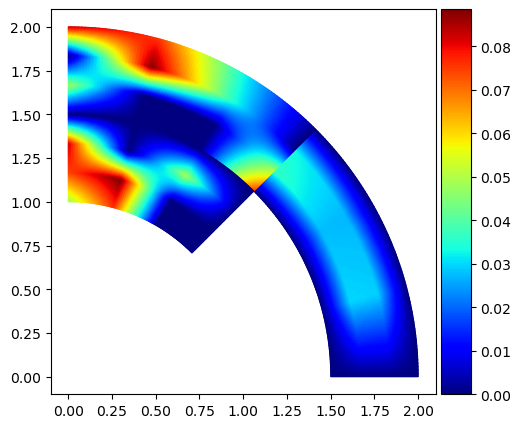

In [4]:
M = LshapeAnullus(1,3,1)
dir_data={0:0}
f=1
#M.outer_boundaries[0].remove((1,(0,0)))
IMap = ieti.IetiMapper(M, dir_data=dir_data, subspace='C0', elim=1)

A, RHS = IMap.assemble(a=1,f=f, M=None)
N = [A.shape[0] for A in A]

B, eliminated_constraints = IMap.ConstraintMatrices()
#SD = ieti.ScaledDirichletPreconditioner(A, B, IMap)

I = ieti.IetiSystem(A, B, RHS, N)
F, b = I.SchurComplement(), I.RHSforSchurComplement()

lam, it, min_eig, max_eig, r = solvers.pcg(F, b, x0=None, maxiter=2000, P=1, output=1, rtol=1e-6, atol=1e-12)

uh_p = I.constructSolutionFromLagrangeMultipliers(lam)#
uh_p = IMap.completeDirichlet(uh_p)
uh = np.concatenate(uh_p)
if IMap.elim:
    uh = IMap.Basis_loc_global@uh

IMap.plot(uh)